# EDA — Credit Scoring Dataset
Dataset: 266 công ty niêm yết VN, crawl từ vnstock, 2018–2024.

## 1. Tổng quan dataset

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data import load_data, FEATURE_COLS, TARGET_COL

df = load_data('../data/vnstock/dataset_v2.csv')

print('Shape:', df.shape)
print('Companies:', df['Company'].nunique())
print('Year range:', df['year'].min(), '-', df['year'].max())
print('Columns:', df.columns.tolist())
print()
df.head()


Shape: (1847, 28)
Companies: 266
Year range: 2018 - 2024
Columns: ['Company', 'year', 'cash_ratio', 'quick_ratio', 'current_ratio', 'lt_debt_to_equity', 'lt_debt_to_assets', 'liab_to_equity', 'liab_to_assets', 'st_debt_to_equity', 'st_debt_to_assets', 'ap_to_equity', 'ap_to_assets', 'assets_to_liab', 'ebitda_coverage', 'pe_basic', 'pe_diluted', 'pb_ratio', 'ps_ratio', 'pb_tangible', 'market_cap', 'price_to_cfo', 'ev', 'ev_to_revenue', 'ev_to_ebitda', 'ev_to_ebit', 'eps_diluted', 'Financial_Distress']



,Company,year,cash_ratio,quick_ratio,current_ratio,lt_debt_to_equity,lt_debt_to_assets,liab_to_equity,liab_to_assets,st_debt_to_equity,...,ps_ratio,pb_tangible,market_cap,price_to_cfo,ev,ev_to_revenue,ev_to_ebitda,ev_to_ebit,eps_diluted,Financial_Distress
0,AAA,2018,0.201327,0.975209,1.244305,0.450568,0.178347,1.526354,0.604173,0.836308,...,0.236769,0.655172,1.896896e+12,7.720835,5.086631e+12,0.634910,20.703848,20.703848,1115.0,0
1,AAA,2019,0.090116,1.158564,1.535962,0.421324,0.171708,1.453723,0.592456,0.737300,...,0.182146,0.531411,1.686320e+12,2.856225,5.166242e+12,0.558026,6.164985,8.750387,2690.0,0
2,AAA,2020,0.255436,0.940736,1.191690,0.153368,0.072017,1.129596,0.530427,0.731458,...,0.365094,0.690279,2.712124e+12,8.722813,5.308913e+12,0.714663,9.037415,17.074680,1310.0,0
3,AAA,2021,0.605718,1.327476,1.631340,0.215606,0.117488,0.835135,0.455081,0.400262,...,0.481836,1.186054,6.332829e+12,15.632696,7.703837e+12,0.586150,11.507155,19.017053,813.0,0
4,AAA,2022,0.512393,1.206515,1.764787,0.201318,0.115079,0.749394,0.428373,0.305909,...,0.164007,0.413727,2.507721e+12,13.389208,3.994933e+12,0.261272,8.386359,21.329723,433.0,0


**Kết quả:** Dataset gồm 1847 dòng × 28 cột, gồm 266 công ty trong giai đoạn 2018–2024.
Mỗi dòng là (Company, year) với 25 features tài chính và nhãn `Financial_Distress`.
Cấu trúc panel data — cùng một công ty xuất hiện ở nhiều năm, nên phải GroupShuffleSplit theo Company để tránh data leakage.

In [2]:
print('Rows per company:')
rows_per_co = df.groupby('Company').size()
print(rows_per_co.value_counts().sort_index())
print()
print('Rows per year:')
print(df.groupby('year').size())


Rows per company:
4      3
5      2
6      2
7    259
Name: count, dtype: int64

Rows per year:
year
2018    260
2019    260
2020    263
2021    266
2022    266
2023    266
2024    266
dtype: int64


**Kết quả:** 259/266 công ty có đủ 7 năm; 7 công ty còn lại chỉ có 4–6 năm (niêm yết muộn).
Số quan sát theo năm tăng dần từ 260 (2018, 2019) → 266 (2021–2024) vì các công ty mới lên sàn được bổ sung dần.
Năm 2018–2020 ít công ty hơn do một số mã chưa có báo cáo trong giai đoạn này.

## 2. Kiểm tra missing values

In [3]:
# tỉ lệ missing theo từng feature
missing = df[FEATURE_COLS].isnull().mean().sort_values(ascending=False) * 100
print('Missing rate per feature (chỉ hiện feature có missing):')
print(missing[missing > 0].round(2).to_string())
print()
print(f'Tổng missing: {df[FEATURE_COLS].isnull().sum().sum()} giá trị ({df[FEATURE_COLS].isnull().mean().mean()*100:.1f}% trung bình)')


Missing rate per feature (chỉ hiện feature có missing):
pe_diluted         48.73
ebitda_coverage    10.61
pe_basic            3.68
pb_tangible         2.44
ps_ratio            2.44
pb_ratio            2.44
market_cap          2.44
price_to_cfo        2.44
ev_to_revenue       2.44
ev_to_ebit          2.44
ev_to_ebitda        2.44
ev                  2.44
cash_ratio          0.05
assets_to_liab      0.05
quick_ratio         0.05
current_ratio       0.05

Tổng missing: 1573 giá trị (3.4% trung bình)


**Kết quả:** Tổng cộng 1573 giá trị missing (~3.4% trung bình).
Cao nhất là `pe_diluted` (48.73%) và `ebitda_coverage` (10.61%); cụm market features (`pb_ratio`, `ps_ratio`, `market_cap`, `ev`, `ev_to_*`) đều ~2.44%.
Bốn liquidity ratio cơ bản (cash/quick/current/assets_to_liab) gần như đầy đủ (~0.05%).

In [4]:
# phân tích nguyên nhân từng nhóm missing

# pe_diluted: missing khi eps_diluted = 0
n_pe_diluted  = df['pe_diluted'].isnull().sum()
n_pe_both     = (df['pe_diluted'].isnull() & df['pe_basic'].isnull()).sum()
n_pe_only_dil = n_pe_diluted - n_pe_both
print(f'pe_diluted null: {n_pe_diluted}')
print(f'  vẫn có pe_basic: {n_pe_only_dil}  |  cả hai null: {n_pe_both}')
print()

# ebitda_coverage: missing khi mẫu số = 0 (không có nợ vay + lãi vay)
n_ebitda       = df['ebitda_coverage'].isnull().sum()
dist_when_null = df[df['ebitda_coverage'].isnull()][TARGET_COL].mean()
dist_when_ok   = df[df['ebitda_coverage'].notna()][TARGET_COL].mean()
print(f'ebitda_coverage null: {n_ebitda}')
print(f'  distress rate khi null: {dist_when_null*100:.1f}%  |  khi có giá trị: {dist_when_ok*100:.1f}%')
print()

# market features: missing cùng nhau khi không có dữ liệu giá cổ phiếu
market_feats = ['market_cap', 'pb_ratio', 'ps_ratio', 'ev', 'ev_to_revenue', 'ev_to_ebit', 'ev_to_ebitda']
all_null_mask = df[market_feats].isnull().all(axis=1)
print(f'Tất cả market features cùng null: {all_null_mask.sum()} dòng')
print(f'  Các công ty bị ảnh hưởng: {df[all_null_mask]["Company"].unique().tolist()}')


pe_diluted null: 900
  vẫn có pe_basic: 832  |  cả hai null: 68

ebitda_coverage null: 196
  distress rate khi null: 2.6%  |  khi có giá trị: 14.4%

Tất cả market features cùng null: 45 dòng
  Các công ty bị ảnh hưởng: ['AAT', 'ABS', 'ACG', 'ADG', 'AGG', 'APH', 'ASG', 'BAF', 'BCF', 'BKG', 'BNA', 'CAG', 'CKG', 'CST', 'DVM', 'DXS', 'GEE', 'GMA', 'GMH', 'HMR', 'HUB', 'ICT', 'ILB', 'KHG']


**Ba nguyên nhân missing chính:**
1. `pe_diluted` null 900 dòng nhưng 832/900 vẫn có `pe_basic` — chỉ 68 dòng mất hoàn toàn thông tin định giá theo lợi nhuận. Lý do: doanh nghiệp không phát hành EPS diluted (eps_diluted = 0).
2. `ebitda_coverage` null khi mẫu số (nợ ngắn hạn + lãi vay) = 0. Distress rate khi null chỉ 2.6% so với 14.4% khi có giá trị — đây là tín hiệu lành mạnh chứ không phải xấu.
3. Market features null đồng thời ở 45 dòng — đều là các công ty niêm yết muộn, năm đầu chưa có dữ liệu giá cổ phiếu.

Cách xử lý: impute bằng train median trong `data.py` sau khi split, tránh leakage.

## 3. EDA biến target (Financial_Distress)

Phân phối Financial_Distress:
Financial_Distress
0    1604
1     243
Name: count, dtype: int64
Distress rate: 13.16%



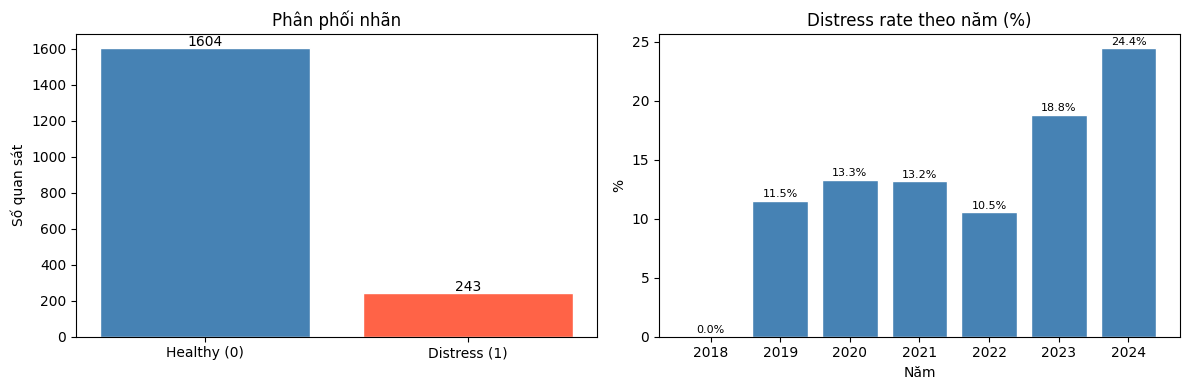

In [5]:
# phân phối tổng thể
print('Phân phối Financial_Distress:')
print(df[TARGET_COL].value_counts())
print(f'Distress rate: {df[TARGET_COL].mean()*100:.2f}%')
print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df[TARGET_COL].value_counts().sort_index()
axes[0].bar(['Healthy (0)', 'Distress (1)'], counts.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Phân phối nhãn')
axes[0].set_ylabel('Số quan sát')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 10, str(v), ha='center')

by_year = df.groupby('year')[TARGET_COL].mean() * 100
axes[1].bar(by_year.index, by_year.values, color='steelblue', edgecolor='white')
axes[1].set_title('Distress rate theo năm (%)')
axes[1].set_xlabel('Năm')
axes[1].set_ylabel('%')
axes[1].set_xticks(by_year.index)
for x, y in zip(by_year.index, by_year.values):
    axes[1].text(x, y + 0.3, f'{y:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()


**Kết quả:** Mất cân bằng rõ rệt — 243/1847 (13.16%) là distress, còn lại 1604 là healthy.
Distress rate năm 2018 = 0% vì label dùng lookback 2–3 năm nên thiếu dữ liệu 2016–2017.
Rate tăng đều từ 2019 (11.5%) đến 2024 (24.4%), đặc biệt nhảy mạnh ở 2023–2024 — phản ánh hệ quả của giai đoạn lãi suất cao và thị trường BĐS suy thoái 2022–2023.

In [6]:
# phân tích công ty distress: bao nhiêu công ty bị, bị bao nhiêu năm, có tái phát không
distress_by_co = df.groupby('Company')[TARGET_COL].agg(['sum', 'count'])
distress_by_co.columns = ['n_distress_years', 'n_total_years']
distress_co = distress_by_co[distress_by_co['n_distress_years'] > 0]

print(f'Số công ty bị distress ít nhất 1 năm: {len(distress_co)} / {df["Company"].nunique()}')
print()
print('Phân phối số năm bị distress:')
print(distress_co['n_distress_years'].value_counts().sort_index())
print()

persistent = 0
intermittent = 0
for co, grp in df.groupby('Company'):
    labels = grp.sort_values('year')[TARGET_COL].tolist()
    if sum(labels) == 0:
        continue
    first_1 = next(i for i, v in enumerate(labels) if v == 1)
    last_1  = len(labels) - 1 - next(i for i, v in enumerate(reversed(labels)) if v == 1)
    has_gap = any(labels[i] == 0 for i in range(first_1, last_1 + 1))
    if has_gap:
        intermittent += 1
    else:
        persistent += 1

print(f'Distress liên tục (không có năm phục hồi ở giữa): {persistent} công ty')
print(f'Distress gián đoạn (có năm phục hồi rồi lại distress): {intermittent} công ty')


Số công ty bị distress ít nhất 1 năm: 97 / 266

Phân phối số năm bị distress:
n_distress_years
1    39
2    20
3    14
4     9
5     4
6    11
Name: count, dtype: int64

Distress liên tục (không có năm phục hồi ở giữa): 82 công ty
Distress gián đoạn (có năm phục hồi rồi lại distress): 15 công ty


**Kết quả:** 97/266 công ty (36.5%) bị distress ít nhất 1 năm.
Phần lớn chỉ bị 1–2 năm (59 công ty), nhưng có tới 11 công ty bị distress cả 6 năm — nhóm này gần như suy thoái cấu trúc.
82 công ty distress liên tục, chỉ 15 công ty gián đoạn (phục hồi rồi tái phát) — cho thấy distress phần lớn là trạng thái kéo dài, không phải sự cố tạm thời.

## 4. EDA từng feature đơn lẻ

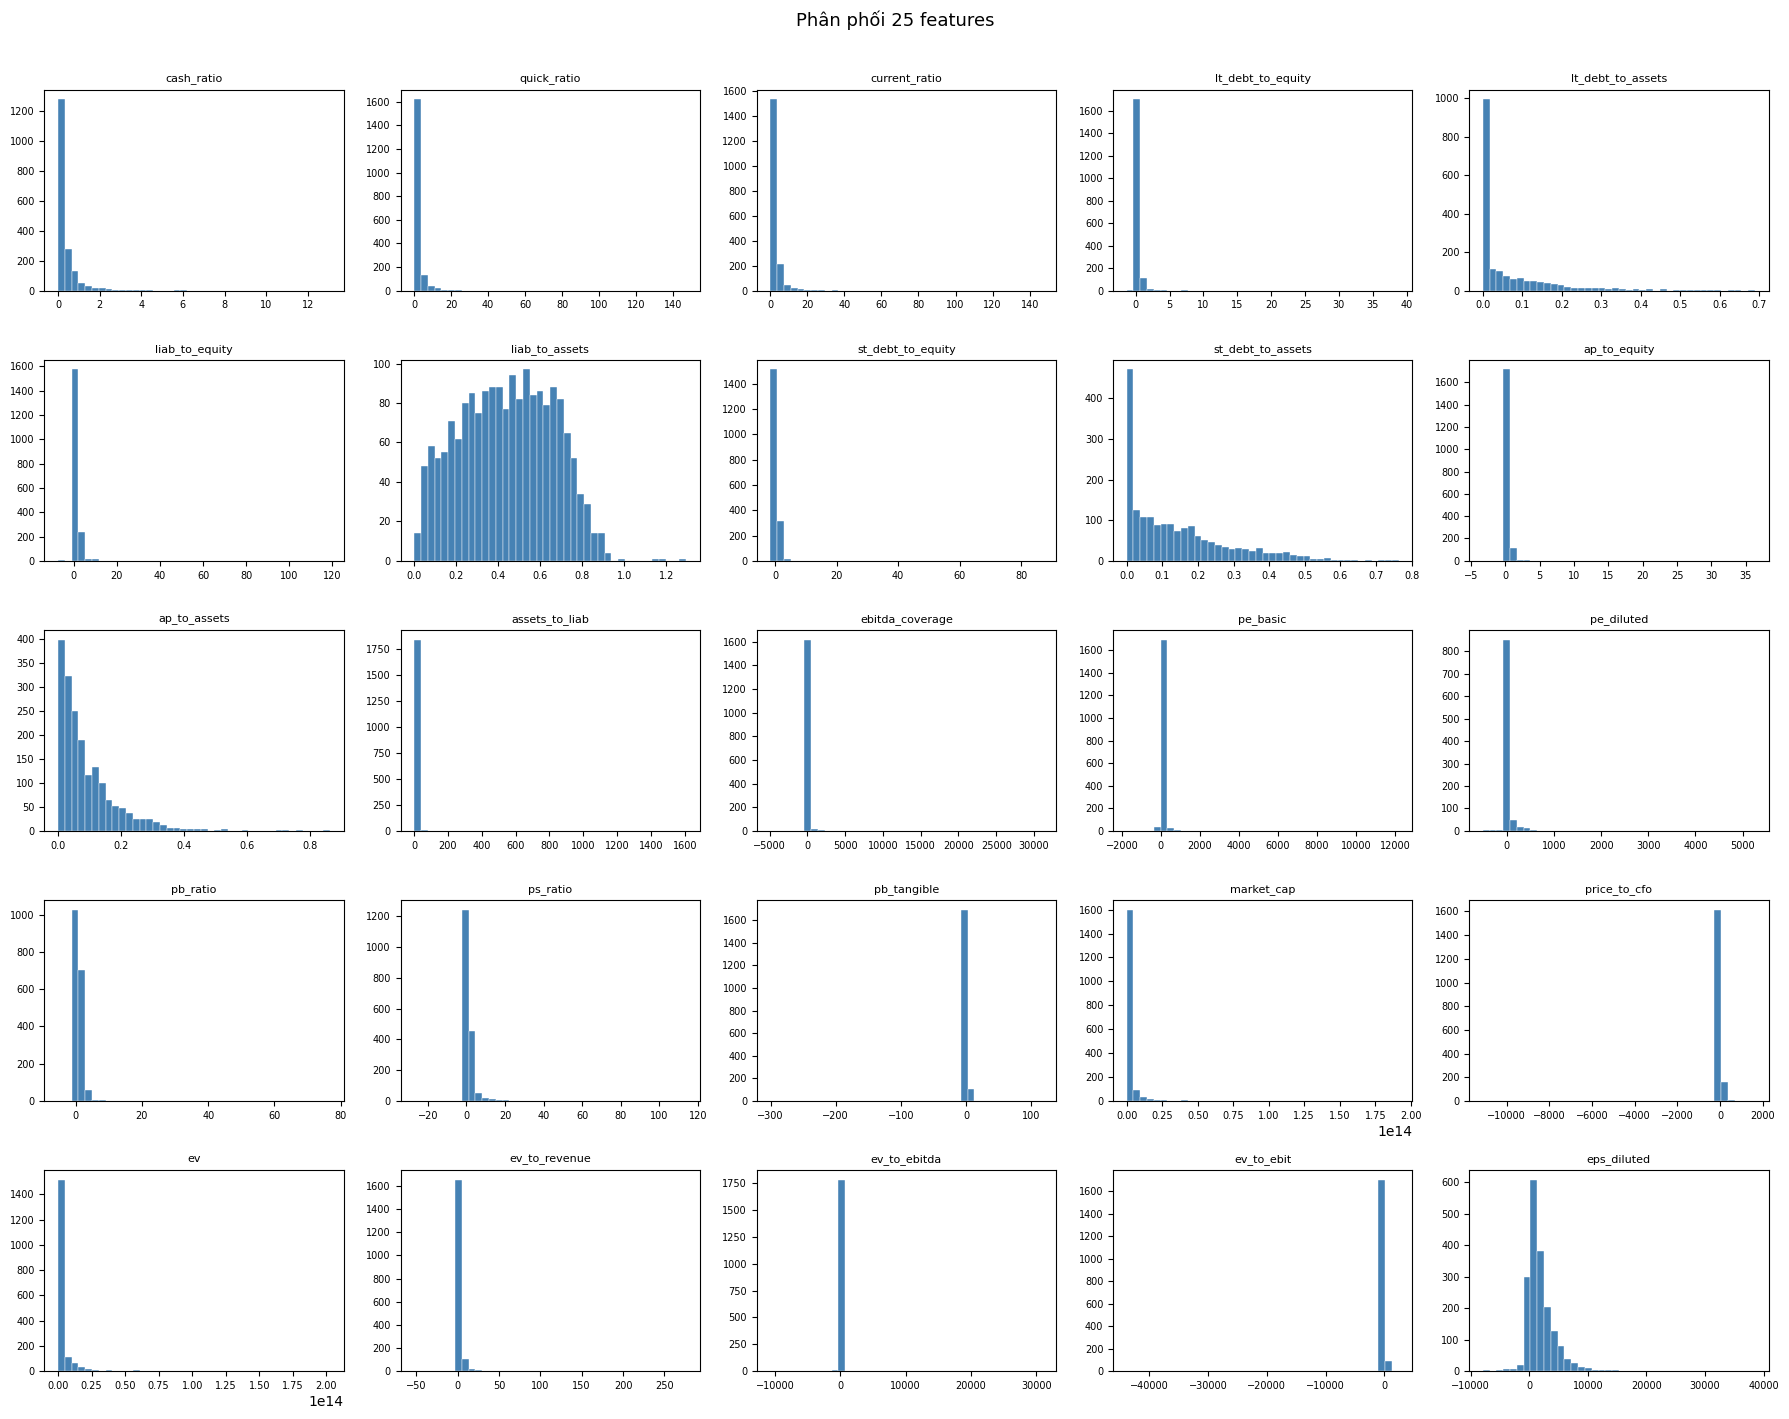

Features có |skew| > 2: 23/25
Features có |skew| > 5: 20/25

Top 5 features lệch nhất:
ev_to_ebit           40.131860
assets_to_liab       37.917533
st_debt_to_equity    34.198012
ev_to_ebitda         33.566820
pb_tangible          31.687602
dtype: float64


In [7]:
fig, axes = plt.subplots(5, 5, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    axes[i].hist(df[col].dropna(), bins=40, edgecolor='white', linewidth=0.3, color='steelblue')
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelsize=7)

plt.suptitle('Phân phối 25 features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

skew_vals = df[FEATURE_COLS].skew().abs()
print(f'Features có |skew| > 2: {(skew_vals > 2).sum()}/25')
print(f'Features có |skew| > 5: {(skew_vals > 5).sum()}/25')
print()
print('Top 5 features lệch nhất:')
print(skew_vals.sort_values(ascending=False).head())


**Kết quả:** 23/25 features có |skew| > 2 và 20/25 có |skew| > 5 — phân phối lệch cực mạnh, điển hình của financial ratios khi mẫu số gần 0 hoặc âm.
Năm feature lệch nhất: `ev_to_ebit` (40.1), `assets_to_liab` (37.9), `st_debt_to_equity` (34.2), `ev_to_ebitda` (33.6), `pb_tangible` (31.7) — đều bị kéo dài bởi outlier khi mẫu số rất nhỏ.
Outlier nhiều và phân phối lệch mạnh là đặc điểm dữ liệu cần lưu ý khi tiền xử lý, có thể cân nhắc winsorize hoặc transform để giảm ảnh hưởng đuôi dài.

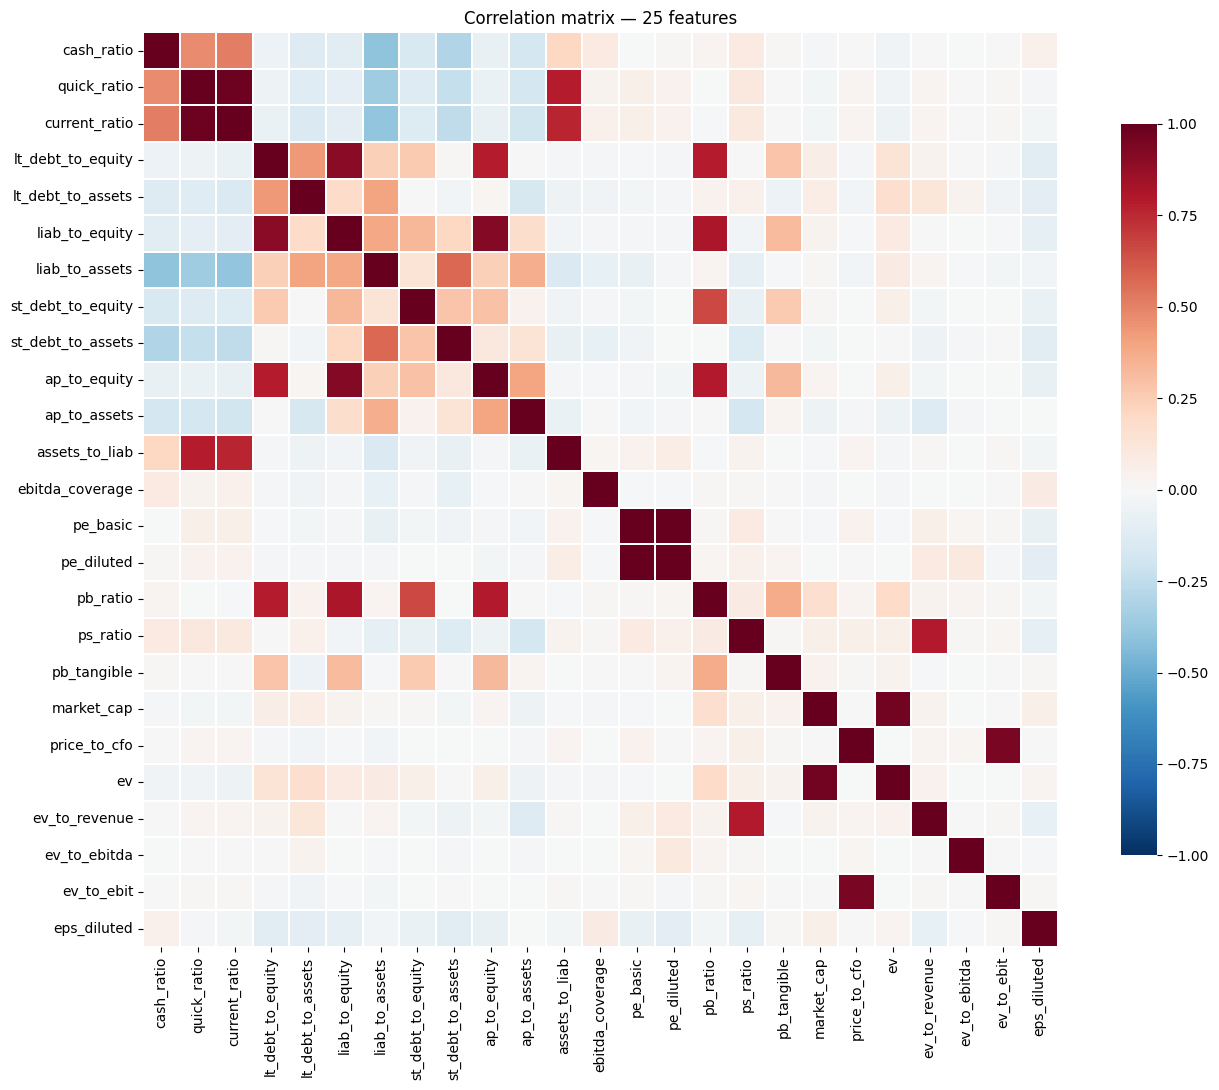

Cặp features có |corr| > 0.7: 13

Các cặp có |corr| > 0.7:
  pe_basic — pe_diluted: 0.997
  quick_ratio — current_ratio: 0.982
  market_cap — ev: 0.967
  price_to_cfo — ev_to_ebit: 0.946
  liab_to_equity — ap_to_equity: 0.921
  lt_debt_to_equity — liab_to_equity: 0.901
  liab_to_equity — pb_ratio: 0.815
  ps_ratio — ev_to_revenue: 0.796
  ap_to_equity — pb_ratio: 0.794
  quick_ratio — assets_to_liab: 0.789
  lt_debt_to_equity — pb_ratio: 0.786
  lt_debt_to_equity — ap_to_equity: 0.784
  current_ratio — assets_to_liab: 0.761


In [8]:
corr = df[FEATURE_COLS].corr()

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, annot=False, cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix — 25 features')
plt.tight_layout()
plt.show()

upper_tri = corr.abs().values.copy()
upper_tri[np.tril_indices(25)] = 0
n_high = (upper_tri > 0.7).sum()
print(f'Cặp features có |corr| > 0.7: {n_high}')
print()

high_pairs = []
feat_arr = np.array(FEATURE_COLS)
rows, cols = np.where(upper_tri > 0.7)
for r, c in zip(rows, cols):
    high_pairs.append((feat_arr[r], feat_arr[c], round(corr.values[r, c], 3)))
high_pairs.sort(key=lambda x: -abs(x[2]))
print('Các cặp có |corr| > 0.7:')
for a, b, v in high_pairs:
    print(f'  {a} — {b}: {v}')


**Kết quả:** 13 cặp features có |corr| > 0.7, chủ yếu nằm trong cùng nhóm khái niệm:
- Valuation: `pe_basic` ↔ `pe_diluted` (0.997)
- Liquidity: `quick_ratio` ↔ `current_ratio` (0.982), `quick_ratio` ↔ `assets_to_liab` (0.789)
- Market size: `market_cap` ↔ `ev` (0.967)
- Leverage: `lt_debt_to_equity` ↔ `liab_to_equity` (0.901), `liab_to_equity` ↔ `ap_to_equity` (0.921)

Các cặp tương quan cao chủ yếu phản ánh cùng một khía cạnh tài chính dưới hai cách tính — đây là đa cộng tuyến trong dữ liệu, cần lưu ý khi diễn giải mức đóng góp của từng feature.

## 5. EDA biến target vs từng feature

In [9]:
healthy   = df[df[TARGET_COL] == 0]
distressed = df[df[TARGET_COL] == 1]

stats = pd.DataFrame({
    'healthy_median':   healthy[FEATURE_COLS].median(),
    'distress_median':  distressed[FEATURE_COLS].median(),
    'healthy_mean':     healthy[FEATURE_COLS].mean(),
    'distress_mean':    distressed[FEATURE_COLS].mean(),
}).round(3)

stats['diff_pct'] = ((stats['distress_median'] - stats['healthy_median']) /
                      stats['healthy_median'].abs().replace(0, np.nan) * 100).round(1)

stats_sorted = stats.reindex(stats['diff_pct'].abs().sort_values(ascending=False).index)
print('So sánh healthy vs distressed (sắp xếp theo mức chênh lệch):')
print(stats_sorted.to_string())


So sánh healthy vs distressed (sắp xếp theo mức chênh lệch):
                   healthy_median  distress_median  healthy_mean  distress_mean  diff_pct
lt_debt_to_equity    9.000000e-03     1.040000e-01  1.540000e-01   6.230000e-01    1055.6
lt_debt_to_assets    5.000000e-03     4.500000e-02  5.700000e-02   1.310000e-01     800.0
ev_to_ebit           8.477000e+00     3.393800e+01  1.613400e+01  -1.354800e+02     300.4
st_debt_to_equity    1.560000e-01     5.580000e-01  3.880000e-01   8.940000e-01     257.7
pe_diluted           8.383000e+00     2.355800e+01  2.890000e+01   1.078630e+02     181.0
liab_to_equity       7.180000e-01     1.759000e+00  1.086000e+00   2.413000e+00     145.0
st_debt_to_assets    8.600000e-02     1.950000e-01  1.250000e-01   2.370000e-01     126.7
ev_to_ebitda         6.474000e+00     1.440900e+01  3.420700e+01  -2.681200e+01     122.6
pe_basic             8.004000e+00     1.662000e+01  3.975400e+01   8.829700e+01     107.6
ebitda_coverage      6.120000e-01     6

**Kết quả:** Chênh lệch median theo % giữa hai nhóm rất lớn ở nhóm leverage và profitability:
- Distress có leverage cao hơn nhiều: `lt_debt_to_equity` +1056%, `lt_debt_to_assets` +800%, `st_debt_to_equity` +258%, `liab_to_equity` +145%, `liab_to_assets` +54%.
- Distress có `ev_to_ebit` +300%, `pe_diluted` +181% (đều do EBIT/EPS thấp hoặc âm, không phải vì giá cao).
- Ngược chiều: `ebitda_coverage` −90%, `eps_diluted` −86%, `cash_ratio` −64%, `quick_ratio` −41%, `current_ratio` −34%.

Tất cả các chiều trên đều đúng kỳ vọng tài chính — distress = nợ nhiều, lợi nhuận thấp, thanh khoản kém.

Tương quan Pearson với Financial_Distress:
liab_to_assets       0.2659
st_debt_to_assets    0.2630
eps_diluted         -0.2438
lt_debt_to_assets    0.2243
lt_debt_to_equity    0.1553
liab_to_equity       0.1470
ev_to_revenue        0.1182
pe_diluted           0.1124
cash_ratio          -0.1035
current_ratio       -0.0853
st_debt_to_equity    0.0779
quick_ratio         -0.0762
ap_to_equity         0.0643
price_to_cfo        -0.0597
ev_to_ebit          -0.0492
pb_tangible         -0.0457
pe_basic             0.0457
market_cap          -0.0433
ps_ratio             0.0390
ebitda_coverage     -0.0311
assets_to_liab      -0.0275
ev_to_ebitda        -0.0268
ap_to_assets         0.0157
pb_ratio             0.0121
ev                   0.0009



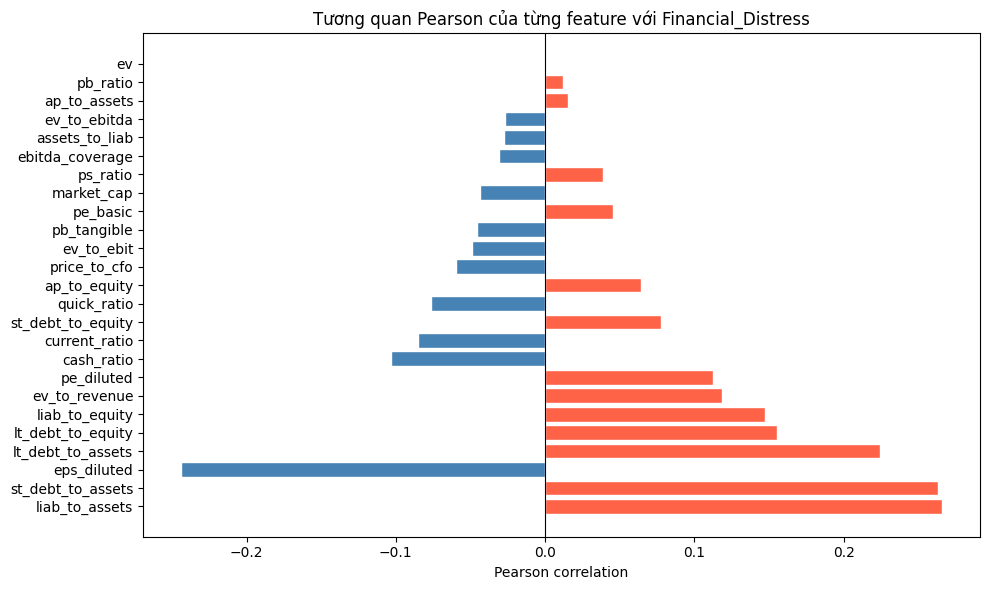

In [10]:
target_corr = df[FEATURE_COLS].corrwith(df[TARGET_COL]).sort_values(key=abs, ascending=False)
print('Tương quan Pearson với Financial_Distress:')
print(target_corr.round(4).to_string())
print()

plt.figure(figsize=(10, 6))
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr.values]
plt.barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Tương quan Pearson của từng feature với Financial_Distress')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()


**Kết quả:** Top 5 tương quan Pearson với target: `liab_to_assets` (+0.27), `st_debt_to_assets` (+0.26), `eps_diluted` (−0.24), `lt_debt_to_assets` (+0.22), `lt_debt_to_equity` (+0.16).
Chiều dấu hợp lý: leverage càng cao → distress càng nhiều (dương), EPS càng cao → distress càng ít (âm).
Tương quan tuyến tính cao nhất chỉ ~0.27 — không feature nào dominant. Tín hiệu distress được phân tán trên nhiều ratio, không có chỉ số đơn lẻ đủ để chẩn đoán.

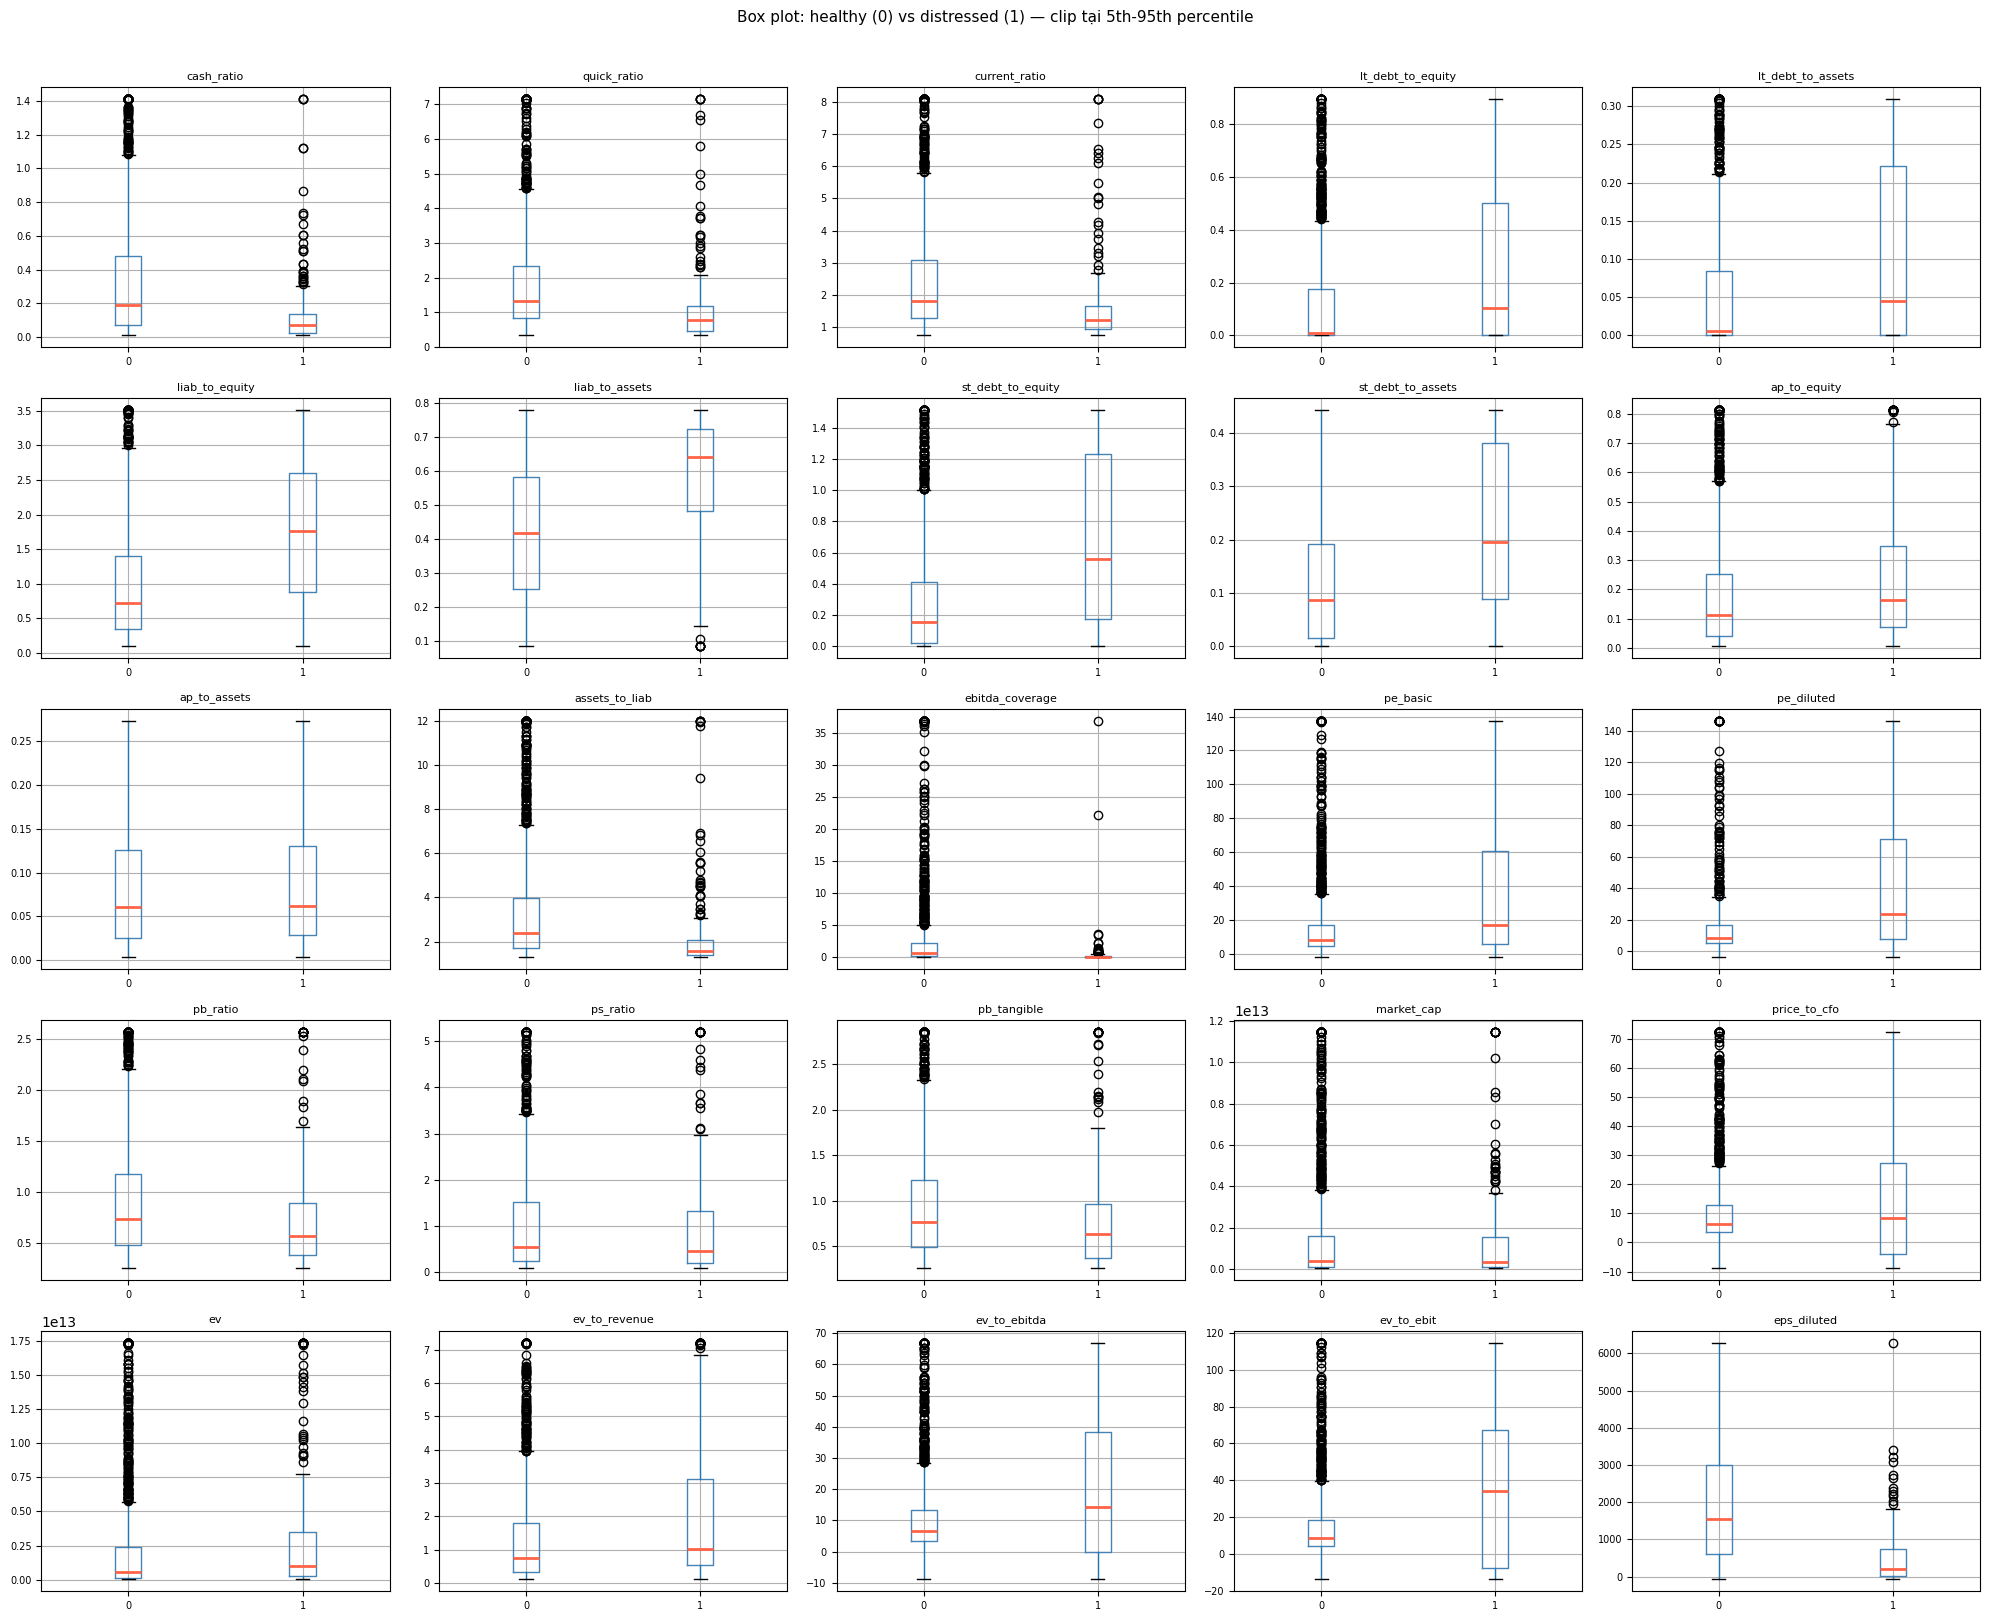

In [11]:
fig, axes = plt.subplots(5, 5, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    lo = df[col].quantile(0.05)
    hi = df[col].quantile(0.95)
    data = df[[col, TARGET_COL]].copy()
    data[col] = data[col].clip(lo, hi)

    data.boxplot(column=col, by=TARGET_COL, ax=axes[i],
                 boxprops=dict(color='steelblue'),
                 medianprops=dict(color='tomato', linewidth=2))
    axes[i].set_title(col, fontsize=8)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

plt.suptitle('Box plot: healthy (0) vs distressed (1) — clip tại 5th-95th percentile', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()


**Kết quả:** Một số feature phân tách hai nhóm rất tốt (median + IQR ít overlap):
- `liab_to_assets`, `st_debt_to_assets`, `lt_debt_to_equity`: distress đẩy cao hẳn lên — tín hiệu nợ nần.
- `ebitda_coverage`, `eps_diluted`, `current_ratio`, `cash_ratio`: distress kéo xuống thấp — tín hiệu thanh khoản và sinh lời yếu.

Phân tách kém (hai box gần như chồng nhau): `market_cap`, `pb_ratio`, `ps_ratio`, `ap_to_assets`, `ev`, `ev_to_ebitda` — quy mô và một số chỉ số valuation đơn lẻ không phân biệt được khoẻ/suy yếu.

## Kết luận

**Quy mô và cấu trúc:** 1847 quan sát, 266 công ty, panel data 2018–2024. 259/266 công ty có đủ 7 năm; bắt buộc split theo Company để tránh data leakage.

**Nhãn target:** Distress rate 13.16% (243/1847) — mất cân bằng vừa phải. Tỷ lệ tăng dần qua các năm, đỉnh ở 2024 (24.4%), phản ánh giai đoạn lãi suất cao 2022–2023. 97 công ty bị distress, trong đó 82 liên tục — distress là trạng thái kéo dài chứ không phải sự cố ngắn hạn.

**Missing values:** Tổng 3.4%, tập trung ở `pe_diluted` (48.7%, nhưng 832/900 vẫn có `pe_basic`), `ebitda_coverage` (10.6%, mất do mẫu số = 0 — thực ra là dấu hiệu lành mạnh) và cụm market features (~2.4%, do công ty niêm yết muộn). Cần impute bằng median sau khi split.

**Đặc điểm dữ liệu:** 23/25 features có |skew| > 2 (financial ratios điển hình); 13 cặp |corr| > 0.7 chủ yếu trong cùng nhóm khái niệm (đa cộng tuyến cần lưu ý).

**Tín hiệu phân biệt healthy vs distress:** Rõ nhất ở nhóm leverage (distress có `lt_debt_to_equity` cao gấp ~11 lần) và profitability/thanh khoản (distress có `ebitda_coverage`, `eps_diluted`, `cash_ratio` thấp hơn nhiều). Tương quan Pearson cao nhất với target chỉ ~0.27, nên distress là tổ hợp đa biến phi tuyến chứ không phải hàm của một ratio đơn lẻ.